In [1]:
# 계층적 군집 알고리즘
# AgglomerativeClustering로 군집 모델 생성하기
# 군집 결과 시각화
# 덴드로그램 시각화하기
'''
문4-1> 다음은 붓꽃 데이터셋에 대해 표준화를 수행한 결과(X_scaled)이다. X_scaled에 대해 병합 계층적 군집화(AgglomerativeClustering)방식으로 클러스터링을 수행하고, 예측값을 확인하시오.
- 클러스터링 수: 3개
- 군집 간 거리 계산 방법: 와드연결법
'''
# 패키지 로딩
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# 붓꽃 데이터셋 로드
data = load_iris()
X = data.data
y = data.target

In [3]:
# 데이터 표준화 (스케일 조정)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# AgglomerativeClustering - 병합 계층적 군집화
model = AgglomerativeClustering(n_clusters=3, linkage='ward')

# 예측
y_pred = model.fit_predict(X_scaled)
print(y_pred)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 0 2 0 2 0 2 2 2 2 0 0 0 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 2 2 2 2 0 2 2 2 2 2 0 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


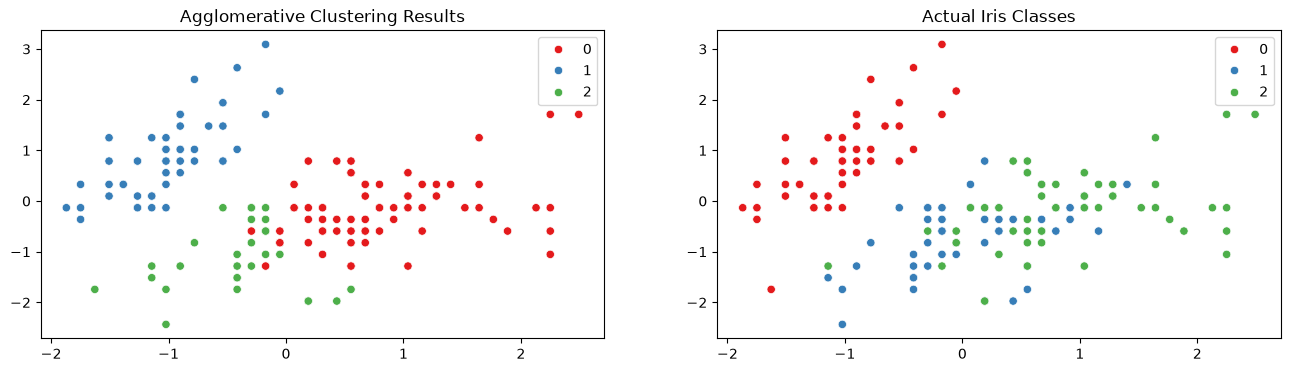

In [6]:
'''
문4-2> 문4-1에서 예측한 군집 결과와 원본 데이터에 대해서 시각화하시오.
- 방법: 산점도(scatter plot)
- x축: X_scaled 4개의 특성 중 [0]값, y축: X_scaled 4개의 특성 중 [1]값
- 각 군집에 따라 다른 색상으로 표시
'''
# 군집화 결과 시각화 (산점도)
fig, ax = plt.subplots(ncols=2, figsize=(16, 4))

# 첫번째 서브플롯: 군집화된 결과
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y_pred, palette='Set1', ax=ax[0])
ax[0].set_title('Agglomerative Clustering Results')

# 두번째 서브플롯: 실제 붓꽃 데이터의 클래스
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y, palette='Set1', ax=ax[1])
ax[1].set_title('Actual Iris Classes')

plt.show()

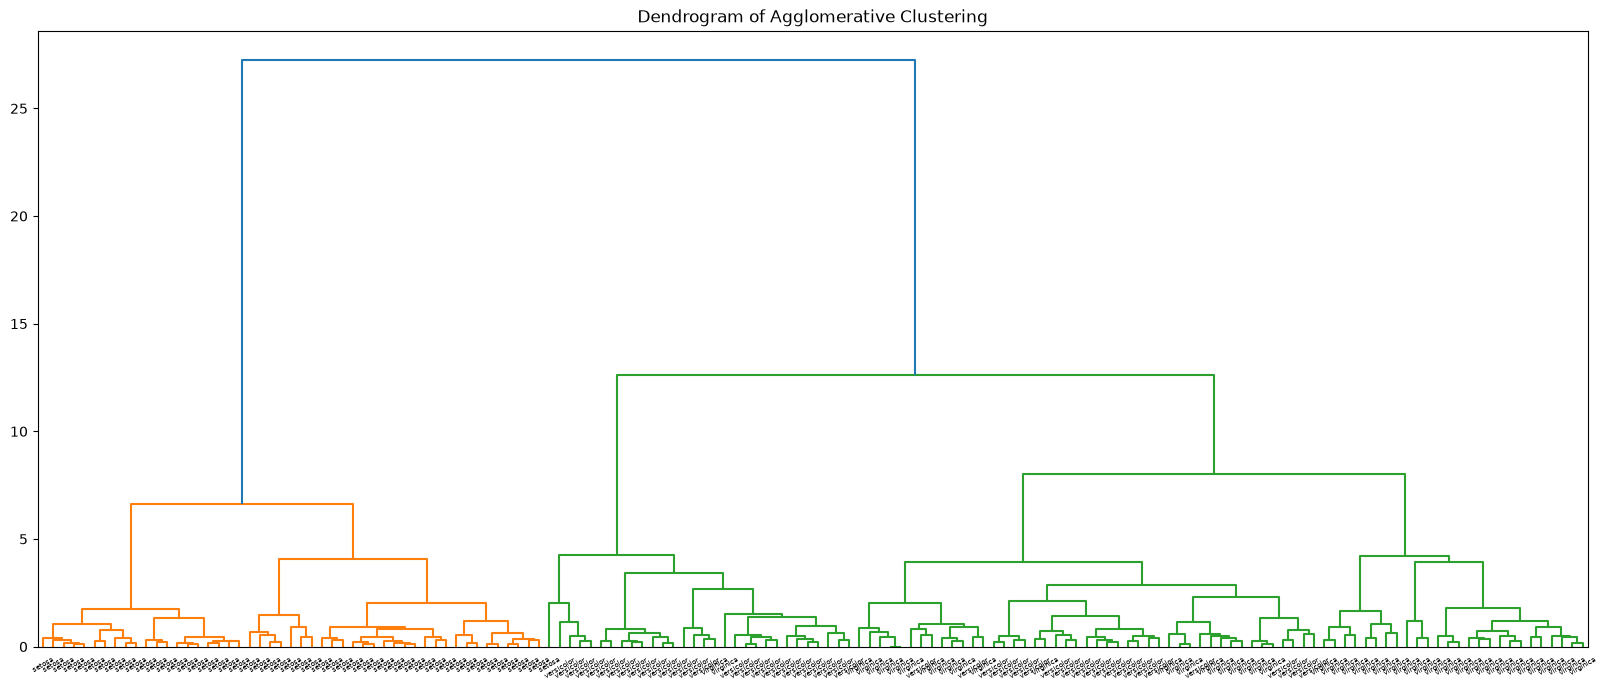

In [11]:
'''
문4-3> 문4-1의 주어진 X_scaled 데이터에 대해 덴드로그램을 그리시오.
- 군집간 거리 계산 방법: 와드연결법
- label: 붓꽃 데이터의 품종
'''
# 덴드로그램 생성 (계층적 군집화의 트리 구조 확인)
linked = linkage(X_scaled, method='ward')

# 덴드로그램 시각화
plt.figure(figsize=(20, 8))
dendrogram(linked, labels=data.target_names[y], leaf_rotation=30)
plt.title('Dendrogram of Agglomerative Clustering')
plt.show()